In [44]:
import numpy as np
import pandas as pd

In [45]:
df = pd.read_csv('sms/data/spam_final_merged.csv', encoding='latin-1')

In [46]:
df.sample(5)

,message,is_spam
5034,I'm at bruce &amp; fowler now but I'm in my mo...,False
2228,This pain couldn't have come at a worse time.,False
5378,"Hey, Apka MSEB bill is due in 2 hrs! Pay now t...",True
1385,For sale - arsenal dartboard. Good condition b...,True
2227,In which place do you want da.,False


In [47]:
df.shape

(6526, 2)

In [48]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6526 entries, 0 to 6525
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  6526 non-null   object
 1   is_spam  6526 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 57.5+ KB


In [50]:
df.sample(5)

,message,is_spam
4303,"I need an 8th but I'm off campus atm, could I ...",False
2088,Yavnt tried yet and never played original either,False
4076,"HELLOGORGEOUS, HOWS U? MY FONE WAS ON CHARGE L...",False
4106,"see you then, we're all christmassy here!",False
2241,Which is weird because I know I had it at one ...,False


In [51]:
# renaming the cols
df.rename(columns={'is_spam':'target','message':'text'},inplace=True)
df.sample(5)

,text,target
879,"Thursday night? Yeah, sure thing, we'll work i...",False
1381,Yes.. now only saw your message..,False
1929,"Goodmorning, today i am late for &lt;DECIMAL&...",False
4570,"\I;m reaching in another 2 stops.\""""",False
3202,Oops - am at my mum's in somerset... Bit far! ...,False


In [52]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [53]:
df['target'] = encoder.fit_transform(df['target'])

In [54]:
df.head()

,text,target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [55]:
# missing values
df.isnull().sum()

text      0
target    0
dtype: int64

In [56]:
# check for duplicate values
df.duplicated().sum()

np.int64(0)

In [57]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.shape

(6526, 2)

## 2.EDA

In [60]:
df.head()

,text,target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [61]:
df['target'].value_counts()

target
0    5195
1    1331
Name: count, dtype: int64

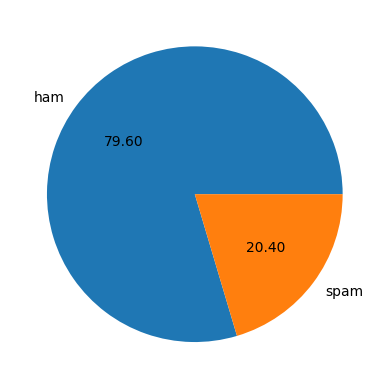

In [62]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [63]:
# Data is imbalanced

In [64]:
import nltk

In [65]:
!pip install nltk

In [66]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adars\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [67]:
df['num_characters'] = df['text'].apply(len)

In [68]:
df.head()

,text,target,num_characters
0,"Go until jurong point, crazy.. Available only ...",0,111
1,Ok lar... Joking wif u oni...,0,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,U dun say so early hor... U c already then say...,0,49
4,"Nah I don't think he goes to usf, he lives aro...",0,61


In [69]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [70]:
df.head()

,text,target,num_characters,num_words
0,"Go until jurong point, crazy.. Available only ...",0,111,24
1,Ok lar... Joking wif u oni...,0,29,8
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37
3,U dun say so early hor... U c already then say...,0,49,13
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15


In [71]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [72]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2
1,Ok lar... Joking wif u oni...,0,29,8,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2
3,U dun say so early hor... U c already then say...,0,49,13,1
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1


In [73]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,6526.000000,6526.000000,6526.000000
mean,94.379405,21.532026,2.392277
std,63.674270,14.032872,1.644486
min,2.000000,1.000000,1.000000
25%,41.000000,10.000000,1.000000
50%,80.000000,19.000000,2.000000
75%,142.000000,30.000000,3.000000
max,910.000000,220.000000,38.000000


In [74]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5195.000000,5195.000000,5195.000000
mean,80.336862,18.905486,2.024062
std,61.233512,13.903600,1.438108
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,2.000000
75%,113.000000,26.000000,3.000000
max,910.000000,220.000000,38.000000


In [75]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1331.000000,1331.000000,1331.000000
mean,149.188580,31.783621,3.829452
std,38.360318,8.891141,1.610652
min,13.000000,2.000000,1.000000
25%,131.500000,27.000000,3.000000
50%,153.000000,31.000000,4.000000
75%,163.000000,37.000000,5.000000
max,457.000000,94.000000,9.000000


In [76]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

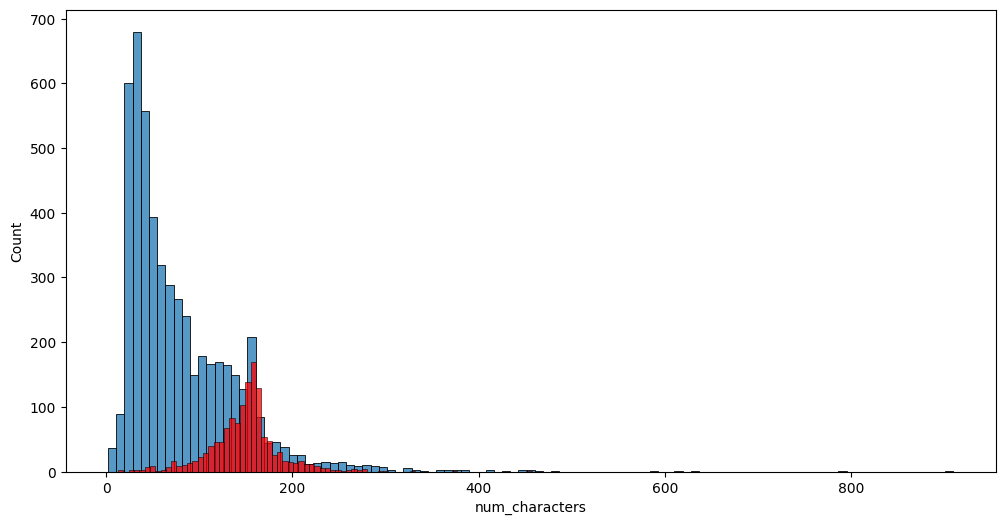

In [77]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

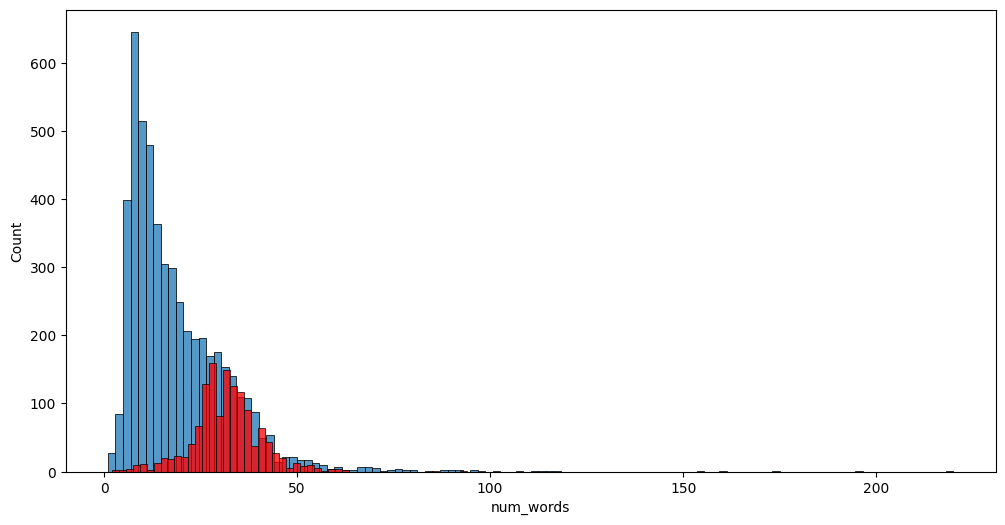

In [78]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

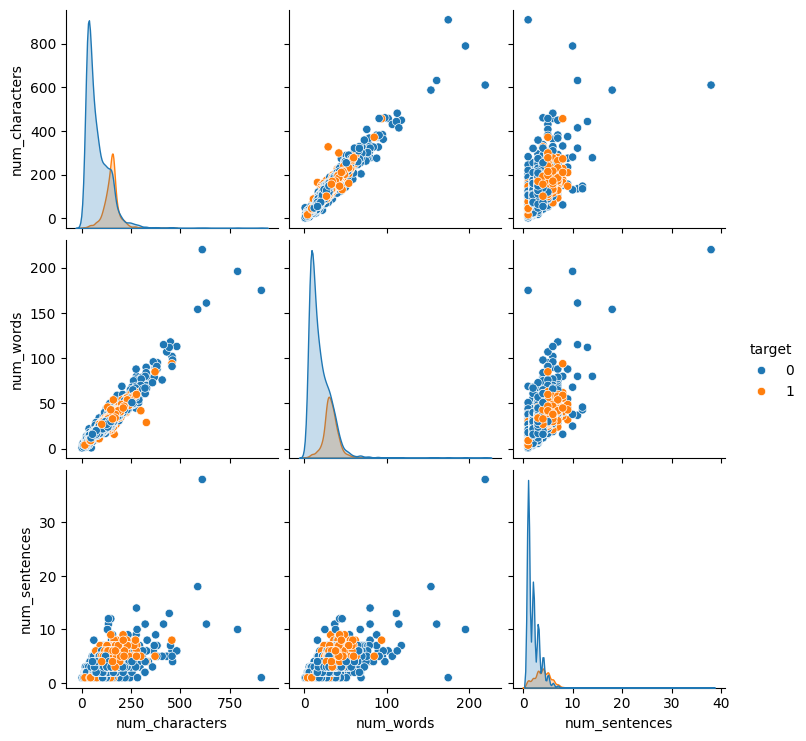

In [79]:
sns.pairplot(df,hue='target')

In [80]:
corr = df[['target','num_characters','num_words','num_sentences']].corr()
corr

,target,num_characters,num_words,num_sentences
target,1.000000,0.435731,0.369806,0.442394
num_characters,0.435731,1.000000,0.969032,0.687656
num_words,0.369806,0.969032,1.000000,0.731383
num_sentences,0.442394,0.687656,0.731383,1.000000


<Axes: >

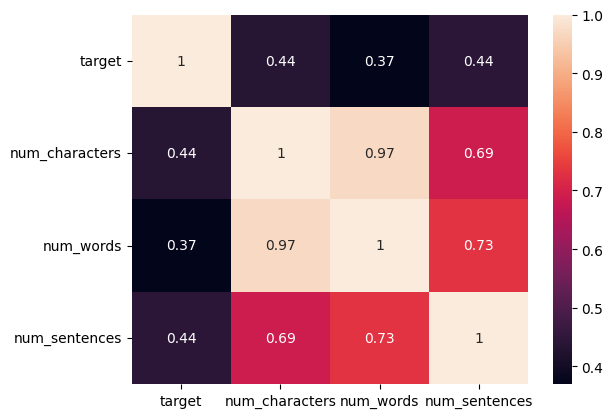

In [81]:
sns.heatmap(corr,annot=True)

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [82]:
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [83]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [84]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [85]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [86]:
df['transformed_text'] = df['text'].apply(transform_text)

In [87]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


In [88]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [89]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

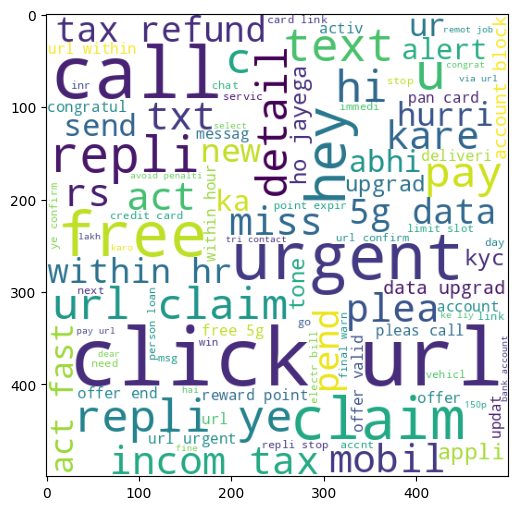

In [90]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [91]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

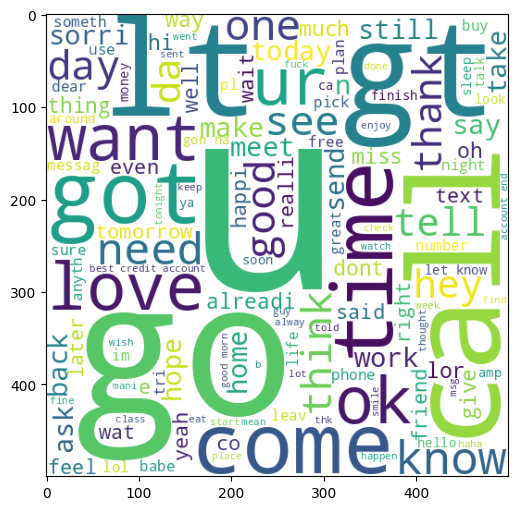

In [92]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [93]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


In [94]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [95]:
len(spam_corpus)

22992

In [96]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [97]:
len(ham_corpus)

45637

In [98]:
# from collections import Counter
# sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[0],pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
# plt.xticks(rotation='vertical')
# plt.show()

In [99]:
# Text Vectorization
# using Bag of Words
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


## 4. Model Building

In [100]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [101]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [102]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [103]:
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [104]:
X.shape

(6526, 3000)

In [105]:
y = df['target'].values

In [106]:
from sklearn.model_selection import train_test_split

In [107]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [108]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [109]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [110]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.7978560490045942
[[820 224]
 [ 40 222]]
0.4977578475336323


In [111]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9686064318529862
[[1039    5]
 [  36  226]]
0.9783549783549783


In [112]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9632465543644717
[[1025   19]
 [  29  233]]
0.9246031746031746


In [113]:
# tfidf --> MNB

In [114]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [116]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [117]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [118]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [119]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9770290964777948, 0.967741935483871)

In [120]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9770290964777948
Precision -  0.967741935483871
For  KN
Accuracy -  0.8683001531393568
Precision -  1.0
For  NB
Accuracy -  0.9686064318529862
Precision -  0.9783549783549783
For  DT
Accuracy -  0.9249617151607963
Precision -  0.8660714285714286
For  LR
Accuracy -  0.9609494640122511
Precision -  0.9377593360995851
For  RF
Accuracy -  0.9777947932618682
Precision -  0.983402489626556
For  AdaBoost
Accuracy -  0.9058192955589587
Precision -  0.8756756756756757
For  BgC
Accuracy -  0.9578866768759571
Precision -  0.8996138996138996
For  ETC
Accuracy -  0.9754977029096478
Precision -  0.9637096774193549
For  GBDT
Accuracy -  0.9387442572741195
Precision -  0.946078431372549
For  xgb
Accuracy -  0.9678407350689127
Precision -  0.9508196721311475


In [121]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [122]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.868300,1.000000
5,RF,0.977795,0.983402
2,NB,0.968606,0.978355
0,SVC,0.977029,0.967742
8,ETC,0.975498,0.963710
10,xgb,0.967841,0.950820
9,GBDT,0.938744,0.946078
4,LR,0.960949,0.937759
7,BgC,0.957887,0.899614
6,AdaBoost,0.905819,0.875676


In [123]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [124]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.868300
1,RF,Accuracy,0.977795
2,NB,Accuracy,0.968606
3,SVC,Accuracy,0.977029
4,ETC,Accuracy,0.975498
5,xgb,Accuracy,0.967841
6,GBDT,Accuracy,0.938744
7,LR,Accuracy,0.960949
8,BgC,Accuracy,0.957887
9,AdaBoost,Accuracy,0.905819


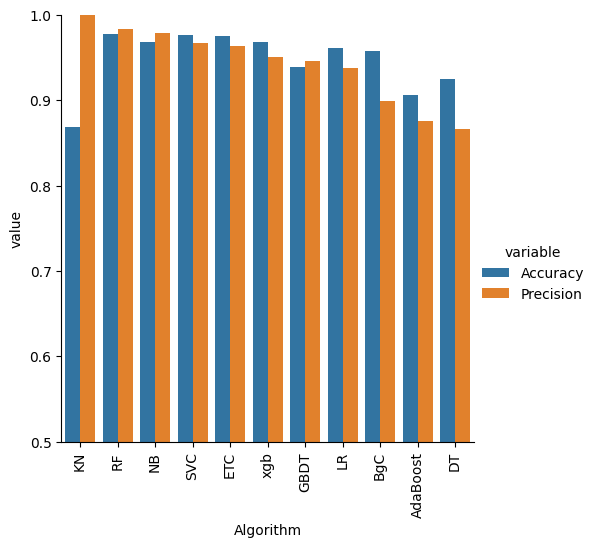

In [125]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [126]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [127]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [128]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [129]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [130]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [131]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [132]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.868300,1.000000,0.868300,1.000000,0.868300,1.000000,0.868300,1.000000
1,RF,0.977795,0.983402,0.977795,0.983402,0.977795,0.983402,0.977795,0.983402
2,NB,0.968606,0.978355,0.968606,0.978355,0.968606,0.978355,0.968606,0.978355
3,SVC,0.977029,0.967742,0.977029,0.967742,0.977029,0.967742,0.977029,0.967742
4,ETC,0.975498,0.963710,0.975498,0.963710,0.975498,0.963710,0.975498,0.963710
5,xgb,0.967841,0.950820,0.967841,0.950820,0.967841,0.950820,0.967841,0.950820
6,GBDT,0.938744,0.946078,0.938744,0.946078,0.938744,0.946078,0.938744,0.946078
7,LR,0.960949,0.937759,0.960949,0.937759,0.960949,0.937759,0.960949,0.937759
8,BgC,0.957887,0.899614,0.957887,0.899614,0.957887,0.899614,0.957887,0.899614
9,AdaBoost,0.905819,0.875676,0.905819,0.875676,0.905819,0.875676,0.905819,0.875676


In [133]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [134]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [135]:
voting.fit(X_train,y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [136]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9839203675344563
Precision 0.9918367346938776


In [137]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [138]:
from sklearn.ensemble import StackingClassifier

In [139]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [140]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816232771822359
Precision 0.9722222222222222


In [141]:
import pickle

# 1. Force the model to train on your data one last time

mnb.fit(X_train, y_train)

# 2. Now export them!
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))

print("Successfully trained and exported!")

Successfully trained and exported!
